In [2]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

# load data

In [3]:
# load training dataset
train_path = "data/engeneered_train.csv"
chunk = pd.read_csv(train_path, chunksize=100000)
df = pd.concat(chunk)


In [4]:
#prepped_df['relevance'] = prepped_df['click_bool'] + prepped_df['booking_bool']*4

# add relevance column
df['relevance'] = df['click_bool'] + df['booking_bool']*4

# data preparation

In [5]:
# split data based on search ids
train_groups, val_groups = train_test_split(df[['srch_id']].drop_duplicates(), test_size=0.1, random_state=42)

# split the actual data on those groups
train_data = df[df['srch_id'].isin(train_groups['srch_id'])]
val_data = df[df['srch_id'].isin(val_groups['srch_id'])]

# prepare X and y for train/val set
X_train = train_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position'])
y_train = train_data['relevance']

X_val = val_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position'])
y_val = val_data['relevance']

In [6]:
# create groups (for DMatrix)
train_group = train_data.groupby('srch_id').size().to_list()
val_group = val_data.groupby('srch_id').size().to_list()

dtrain = xgb.DMatrix(X_train, label=y_train)
dtrain.set_group(train_group)

dval = xgb.DMatrix(X_val, label=y_val)
dval.set_group(val_group)

# train model

In [32]:
params = {
    'objective': 'rank:pairwise',
    'eta': 0.15, # learning rate
    'gamma': 0.5, # minimum loss reduction required to further partition on a leaf node 
    'min_child_weight': 1, #  minimum sum of instance weights needed in a child
    'max_depth': 10, # max depth of the tree
    'eval_metric': 'ndcg' # 'map' for mean average precision; 'ndcg' for ndcg
}

params = {
    'objective': 'rank:pairwise',
    'eta': 0.1,
    'gamma': 0.5,
    'min_child_weight': 1,
    'max_depth': 6,
    'eval_metric': 'ndcg',
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

In [33]:
epochs = 200
evals_result = {} # save results into dict
bst = xgb.train(params, dtrain, epochs, evals=[(dtrain, 'train'), (dval, 'val')],
                early_stopping_rounds=10, evals_result=evals_result, verbose_eval=True)

[0]	train-ndcg:0.45110	val-ndcg:0.45160
[1]	train-ndcg:0.47195	val-ndcg:0.47052
[2]	train-ndcg:0.48083	val-ndcg:0.48041
[3]	train-ndcg:0.48382	val-ndcg:0.48218
[4]	train-ndcg:0.48594	val-ndcg:0.48389
[5]	train-ndcg:0.48738	val-ndcg:0.48519
[6]	train-ndcg:0.48718	val-ndcg:0.48533
[7]	train-ndcg:0.48794	val-ndcg:0.48639
[8]	train-ndcg:0.48891	val-ndcg:0.48750
[9]	train-ndcg:0.48966	val-ndcg:0.48778
[10]	train-ndcg:0.49053	val-ndcg:0.48806
[11]	train-ndcg:0.49086	val-ndcg:0.48815
[12]	train-ndcg:0.49142	val-ndcg:0.48854
[13]	train-ndcg:0.49132	val-ndcg:0.48909
[14]	train-ndcg:0.49237	val-ndcg:0.48970
[15]	train-ndcg:0.49217	val-ndcg:0.48971
[16]	train-ndcg:0.49191	val-ndcg:0.48919
[17]	train-ndcg:0.49219	val-ndcg:0.49029
[18]	train-ndcg:0.49266	val-ndcg:0.49041
[19]	train-ndcg:0.49282	val-ndcg:0.49052
[20]	train-ndcg:0.49315	val-ndcg:0.49020
[21]	train-ndcg:0.49389	val-ndcg:0.49098
[22]	train-ndcg:0.49402	val-ndcg:0.49107
[23]	train-ndcg:0.49409	val-ndcg:0.49124
[24]	train-ndcg:0.49414	va

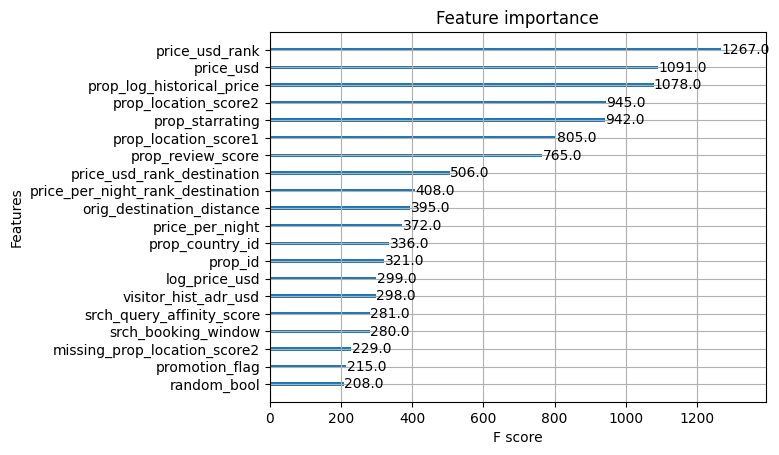

In [34]:
# get feature importance plot it so that the labels are readable
xgb.plot_importance(bst, importance_type='weight', max_num_features=20)

plt.show()

In [22]:
# save best model to save_models/
best_iteration = bst.best_iteration
best_score = bst.best_score
bst.save_model(f'save_models/best_model_{best_iteration}_score_{best_score:.2f}.model')

/Users/michele/computer_science/code/DMT-assignment-2/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [18:41:25] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)


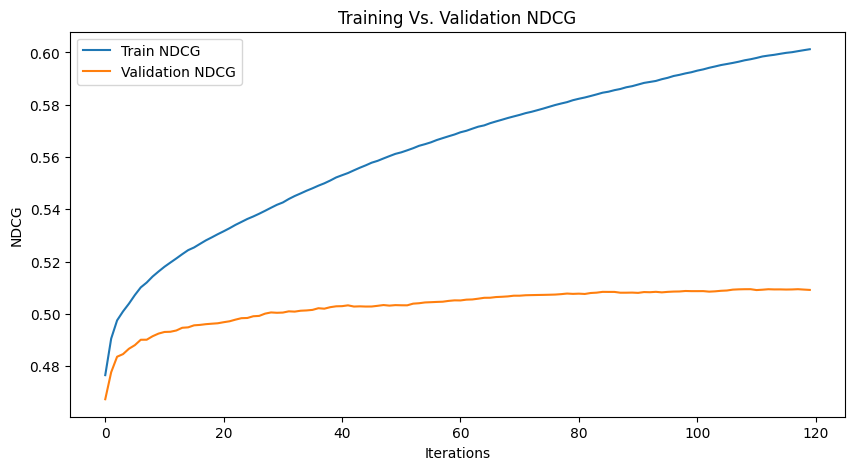

In [13]:
# plot training
train_evals = evals_result['train']['ndcg']
val_evals = evals_result['val']['ndcg']
plt.figure(figsize=(10, 5))
plt.plot(train_evals, label='Train NDCG')
plt.plot(val_evals, label='Validation NDCG')
plt.xlabel('Iterations')
plt.ylabel('NDCG')
plt.title('Training Vs. Validation NDCG')
plt.legend()
plt.ylim()
plt.show()

In [16]:
# validation set
preds = bst.predict(dval)
print(preds)

[-1.2444257  -0.06492182 -1.0223947  ... -1.6179527  -1.0324504
 -1.2767106 ]


### Training on the whole dataset

In [21]:
# # train model on full dataset
# dtrain_full = xgb.DMatrix(df.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position']), label=df['relevance'])
# dtrain_full.set_group(df.groupby('srch_id').size().to_list())


# params = {
#     'objective': 'rank:pairwise',
#     'eta': 0.15, # learning rate
#     'gamma': 0.5, # minimum loss reduction required to further partition on a leaf node 
#     'min_child_weight': 1, #  minimum sum of instance weights needed in a child
#     'max_depth': 10, # max depth of the tree
#     'eval_metric': 'ndcg' # 'map' for mean average precision; 'ndcg' for ndcg
# }



# model = xgb.XGBRanker(**params)







In [35]:

# Initialize DMatrix from the provided code snippet
dtrain_full = xgb.DMatrix(df.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position']), label=df['relevance'])
dtrain_full.set_group(df.groupby('srch_id').size().to_list())

# Train the model
bst = xgb.train(params, dtrain_full, num_boost_round=200, verbose_eval=True)

# Save the model (optional, but recommended)
bst.save_model('xgb_ranking_model.model')

/Users/michele/computer_science/code/DMT-assignment-2/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [18:59:50] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)


# Run model on the test_data:

In [36]:
# load test set
test_path = "data/engeneered_test.csv"
chunk = pd.read_csv(test_path, chunksize=100000)
test_df = pd.concat(chunk)



In [38]:
test_group = test_df.groupby('srch_id').size().to_list()


In [39]:
dtest = xgb.DMatrix(test_df)
dtest.set_group(test_group)





In [40]:
test_preds = bst.predict(dtest)
print(test_preds)

[-0.22688502 -0.24966808 -0.34148696 ... -0.5289772   0.5048371
  0.5818559 ]


In [41]:
# add predictions as column
test_df['prediction'] = test_preds

grouped = test_df.groupby('srch_id').apply(lambda x: x.sort_values('prediction', ascending=False))

# Reset the index to flatten the DataFrame
grouped = grouped.reset_index(drop=True)

# Select the top 5 for each search_id
top5 = grouped.groupby('srch_id')

print(top5)

/var/folders/d8/_xc_qyn9121fv2fflg18bqxc0000gn/T/ipykernel_17971/1910388421.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = test_df.groupby('srch_id').apply(lambda x: x.sort_values('prediction', ascending=False))


In [42]:
# get the the current datetime
# import the library
from datetime import datetime

date_time  = datetime.now().strftime("%Y%m%d-%H%M%S")

grouped[['srch_id', 'prop_id']].to_csv(f'kaggle_predictions/xgboost_predictions{date_time}.csv', index=False, sep=',')

In [31]:
len(grouped)

4959183